# Chapter 11.7: Causal Inference for RecSys

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Distinguish correlation from causation** in recommendation data and explain why causal reasoning matters
2. **Apply instrumental variable methods** to estimate causal effects of recommendations
3. **Understand causal embeddings** and how to learn causal representations
4. **Implement uplift modeling** to estimate the causal effect of showing an item
5. **Apply front-door and back-door criteria** in recommendation contexts
6. **Implement deconfounding** to remove confounders from recommendation data
7. **Build an uplift model** that estimates individual treatment effects for recommendation decisions

## Prerequisites

- Chapters 11.1-11.4 (especially counterfactual evaluation and bias)
- Basic understanding of causal graphs (DAGs)
- Familiarity with potential outcomes framework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part11/chapter_11.7_causal_inference.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part11/chapter_11.7_causal_inference.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import cross_val_predict
from collections import Counter

np.random.seed(42)
plt.style.use('seaborn-v0_8')
print("All imports successful.")

All imports successful.


## 1. Correlation vs Causation in RecSys

The key question: **Does the recommendation cause the purchase, or would the user have purchased anyway?**

Consider this causal graph:

```
User Intent (U) -----> Purchase (Y)
       |                    ^
       v                    |
  Recommendation (T) -------+
```

User intent $U$ is a **confounder**: it affects both whether the system recommends an item (users who search for a product get relevant recommendations) and whether the user purchases.

$$\text{Observational: } P(Y|T=1) \neq P(Y|\text{do}(T=1)) \text{ when confounders exist}$$

Reference: Liang et al., "Causal Inference for Recommendation" (UAI 2016); Wang et al., "Deconfounded Recommendation for Alleviating Bias Amplification" (KDD 2021).

> **💡 Concept:** In recommendation, the treatment is "showing an item to a user." The causal effect is the *incremental* impact of the recommendation beyond what the user would have done anyway.

In [2]:
# Simulate the confounded recommendation scenario
rng = np.random.RandomState(42)
N = 10000

# User features
user_intent = rng.randn(N)  # latent purchase intent (confounder)
user_features = np.column_stack([
    rng.randn(N),           # feature 1: browsing frequency
    rng.randn(N),           # feature 2: price sensitivity  
    user_intent + rng.randn(N) * 0.3,  # feature 3: correlated with intent
])

# Treatment (recommendation): influenced by user intent (confounding!)
# Users with high intent are more likely to be shown the item
treatment_prob = expit(0.8 * user_intent + 0.3 * user_features[:, 0])
treatment = rng.binomial(1, treatment_prob)

# True causal effect of recommendation (heterogeneous)
true_effect = 0.15 + 0.1 * user_features[:, 1]  # varies by user

# Outcome: purchase
# Y(0) = baseline purchase probability (depends on intent)
# Y(1) = Y(0) + causal effect
baseline_purchase_prob = expit(0.5 * user_intent + 0.2 * user_features[:, 0] - 1.0)
y0 = rng.binomial(1, baseline_purchase_prob)  # potential outcome without treatment
y1 = rng.binomial(1, np.clip(baseline_purchase_prob + true_effect, 0, 1))  # with treatment

# Observed outcome
observed_y = treatment * y1 + (1 - treatment) * y0

# Naive correlation-based estimate
naive_effect = observed_y[treatment == 1].mean() - observed_y[treatment == 0].mean()
true_ate = (y1 - y0).mean()

print(f"True Average Treatment Effect (ATE): {true_ate:.4f}")
print(f"Naive estimate (correlation):        {naive_effect:.4f}")
print(f"Bias: {abs(naive_effect - true_ate):.4f}")
print(f"\nThe naive estimate is {'upward' if naive_effect > true_ate else 'downward'} biased ")
print(f"because users with high intent get both more recommendations AND more purchases.")

True Average Treatment Effect (ATE): 0.1490
Naive estimate (correlation):        0.2262
Bias: 0.0772

The naive estimate is upward biased 
because users with high intent get both more recommendations AND more purchases.


## 2. Back-Door Adjustment

If we can observe all confounders $Z$, we can use the **back-door adjustment** formula:

$$P(Y | \text{do}(T=t)) = \sum_z P(Y | T=t, Z=z) P(Z=z)$$

In practice, we fit a model $E[Y|T,Z]$ and compare predictions under $T=1$ vs $T=0$.

> **⚠️ Common Pitfall:** The back-door criterion only works if we observe *all* confounders. Unobserved confounders (e.g., user mood, external events) will still bias the estimate.

In [3]:
# Back-door adjustment via regression
# We condition on user features (which include a proxy for intent)

X = np.column_stack([treatment, user_features])
reg = LinearRegression()
reg.fit(X, observed_y)

# Predict outcomes under treatment and control
X_treated = np.column_stack([np.ones(N), user_features])
X_control = np.column_stack([np.zeros(N), user_features])

y_hat_1 = reg.predict(X_treated)
y_hat_0 = reg.predict(X_control)

backdoor_ate = (y_hat_1 - y_hat_0).mean()

print(f"True ATE:               {true_ate:.4f}")
print(f"Naive estimate:         {naive_effect:.4f}")
print(f"Back-door adjustment:   {backdoor_ate:.4f}")
print(f"Back-door bias:         {abs(backdoor_ate - true_ate):.4f}")

True ATE:               0.1490
Naive estimate:         0.2262
Back-door adjustment:   0.1534
Back-door bias:         0.0044


## 3. Instrumental Variables for Recommendations

An **instrumental variable** (IV) $Z$ satisfies:
1. $Z$ affects the treatment $T$ (relevance)
2. $Z$ does not directly affect the outcome $Y$ (exclusion restriction)
3. $Z$ is independent of confounders $U$ (independence)

In recommendations, a natural IV is **random recommendation assignment** (e.g., A/B test bucket).

The IV estimator (Two-Stage Least Squares):

$$\hat{\beta}_{\text{IV}} = \frac{\text{Cov}(Y, Z)}{\text{Cov}(T, Z)}$$

In [4]:
# Create an instrumental variable: random recommendation slot assignment
# Z = 1 if user was randomly assigned to a "boosted" recommendation slot
Z = rng.binomial(1, 0.5, N)  # random assignment (independent of confounders)

# Z affects treatment: boosted slot increases probability of seeing the item
treatment_prob_iv = expit(0.8 * user_intent + 0.3 * user_features[:, 0] + 1.5 * Z)
treatment_iv = rng.binomial(1, treatment_prob_iv)

# Outcome with the new treatment assignment
observed_y_iv = treatment_iv * y1 + (1 - treatment_iv) * y0

# Two-Stage Least Squares (2SLS)
# Stage 1: Regress T on Z and covariates
stage1 = LinearRegression()
stage1.fit(np.column_stack([Z, user_features]), treatment_iv)
T_hat = stage1.predict(np.column_stack([Z, user_features]))

# Stage 2: Regress Y on T_hat and covariates
stage2 = LinearRegression()
stage2.fit(np.column_stack([T_hat, user_features]), observed_y_iv)
iv_estimate = stage2.coef_[0]  # coefficient of T_hat

# Simple IV (Wald estimator)
wald_estimate = (observed_y_iv[Z == 1].mean() - observed_y_iv[Z == 0].mean()) / \
                (treatment_iv[Z == 1].mean() - treatment_iv[Z == 0].mean())

print(f"True ATE:         {true_ate:.4f}")
print(f"Naive estimate:   {naive_effect:.4f}")
print(f"2SLS IV estimate: {iv_estimate:.4f}")
print(f"Wald IV estimate: {wald_estimate:.4f}")

True ATE:         0.1490
Naive estimate:   0.2262
2SLS IV estimate: 0.1930
Wald IV estimate: 0.1903


## 4. Uplift Modeling

Uplift modeling estimates the **Individual Treatment Effect (ITE)** or **Conditional Average Treatment Effect (CATE)**:

$$\tau(x) = E[Y(1) - Y(0) | X = x]$$

This tells us which users benefit most from the recommendation.

### T-Learner Approach
1. Train model $\mu_1(x)$ on treated group: $E[Y|X, T=1]$
2. Train model $\mu_0(x)$ on control group: $E[Y|X, T=0]$
3. Estimate uplift: $\hat{\tau}(x) = \hat{\mu}_1(x) - \hat{\mu}_0(x)$

Reference: Gutierrez & Gerardy, "Causal Inference and Uplift Modelling: A Review of the Literature" (JMLR 2017).

In [5]:
# T-Learner for uplift modeling
# Use the IV-based data (more balanced treatment assignment)

# Split into treated and control
X_features = user_features.copy()
treated_mask = treatment_iv == 1
control_mask = treatment_iv == 0

# Model 1: outcome model for treated
model_treated = DecisionTreeRegressor(max_depth=5, random_state=42)
model_treated.fit(X_features[treated_mask], observed_y_iv[treated_mask])

# Model 0: outcome model for control
model_control = DecisionTreeRegressor(max_depth=5, random_state=42)
model_control.fit(X_features[control_mask], observed_y_iv[control_mask])

# Estimate uplift for all users
predicted_uplift = model_treated.predict(X_features) - model_control.predict(X_features)
true_uplift = y1 - y0  # ground truth (we know this because of simulation)

print(f"Correlation between predicted and true uplift: {np.corrcoef(predicted_uplift, true_uplift)[0,1]:.4f}")
print(f"Mean predicted uplift: {predicted_uplift.mean():.4f}")
print(f"Mean true uplift:      {true_uplift.mean():.4f}")

Correlation between predicted and true uplift: 0.1505
Mean predicted uplift: 0.1645
Mean true uplift:      0.1490


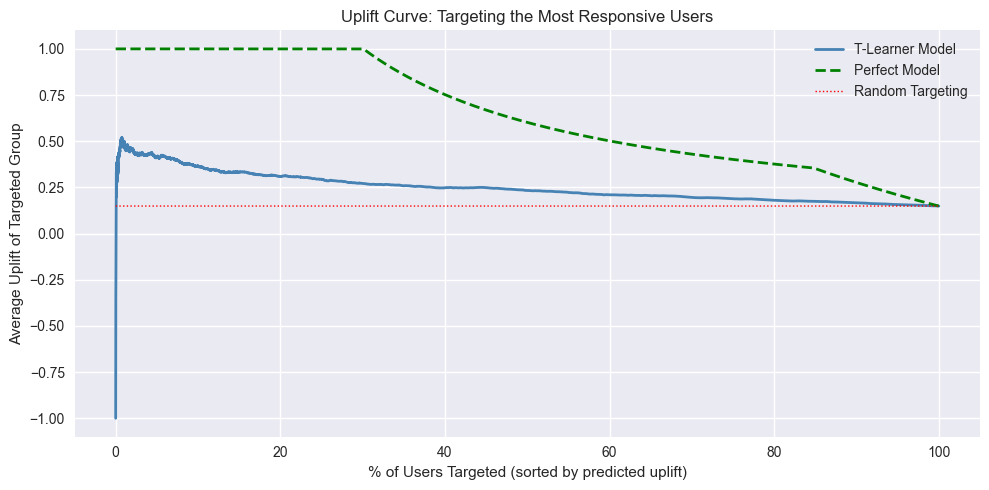

AUUC - Model: 0.2486, Random: 0.1490, Perfect: 0.6501


In [6]:
# Uplift curve: shows cumulative gain from targeting users by predicted uplift
# Sort users by predicted uplift (highest first)
sorted_idx = np.argsort(-predicted_uplift)
sorted_true_uplift = true_uplift[sorted_idx]

# Cumulative uplift curve
cum_uplift = np.cumsum(sorted_true_uplift) / np.arange(1, N + 1)
random_uplift = np.full(N, true_uplift.mean())

# Perfect model (sort by true uplift)
perfect_idx = np.argsort(-true_uplift)
perfect_cum = np.cumsum(true_uplift[perfect_idx]) / np.arange(1, N + 1)

pct_targeted = np.arange(1, N + 1) / N * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pct_targeted, cum_uplift, label='T-Learner Model', color='steelblue', linewidth=2)
ax.plot(pct_targeted, perfect_cum, label='Perfect Model', color='green', linewidth=2, linestyle='--')
ax.plot(pct_targeted, random_uplift, label='Random Targeting', color='red', linewidth=1, linestyle=':')
ax.set_xlabel('% of Users Targeted (sorted by predicted uplift)')
ax.set_ylabel('Average Uplift of Targeted Group')
ax.set_title('Uplift Curve: Targeting the Most Responsive Users')
ax.legend()
plt.tight_layout()
plt.show()

# AUUC (Area Under the Uplift Curve)
auuc_model = np.trapz(cum_uplift, pct_targeted) / 100
auuc_random = np.trapz(random_uplift, pct_targeted) / 100
auuc_perfect = np.trapz(perfect_cum, pct_targeted) / 100
print(f"AUUC - Model: {auuc_model:.4f}, Random: {auuc_random:.4f}, Perfect: {auuc_perfect:.4f}")

## 5. Front-Door Criterion

When we cannot observe confounders but can observe a **mediator** $M$ (a variable on the causal path from $T$ to $Y$), we can use the front-door criterion:

```
Confounder (U) ---> T    U ---> Y
                    |             ^
                    v             |
                    M ----------->+
```

$$P(Y|\text{do}(T=t)) = \sum_m P(M=m|T=t) \sum_{t'} P(Y|T=t', M=m) P(T=t')$$

In recommendations, $M$ could be "user clicks on the recommended item" (mediating between recommendation and purchase).

> **🔑 Pro Tip:** The front-door criterion is powerful when direct confounders are unobserved, but it requires a complete mediator. In practice, "click" often partially mediates — users can also discover items through other channels.

In [7]:
# Simulate front-door scenario
# Confounder U affects both T and Y, but the only path T->Y goes through M (click)

U = rng.randn(N)  # unobserved confounder
T_fd = rng.binomial(1, expit(0.5 * U))  # treatment affected by confounder

# Mediator: click (affected by treatment only, not confounder)
M_prob = expit(1.0 * T_fd - 0.5)
M = rng.binomial(1, M_prob)

# Outcome: affected by mediator M and confounder U
Y_fd = rng.binomial(1, expit(0.8 * M + 0.5 * U - 0.5))

# Naive estimate (biased)
naive_fd = Y_fd[T_fd == 1].mean() - Y_fd[T_fd == 0].mean()

# Front-door adjustment
# Step 1: P(M|T) - easy to estimate
p_m1_t1 = M[T_fd == 1].mean()
p_m1_t0 = M[T_fd == 0].mean()

# Step 2: P(Y|M, T) for each combination, then marginalise over T
# P(Y|do(M=m)) = sum_t P(Y|M=m, T=t) P(T=t)
p_t1 = T_fd.mean()
p_t0 = 1 - p_t1

p_y_m1_t1 = Y_fd[(M == 1) & (T_fd == 1)].mean() if ((M == 1) & (T_fd == 1)).sum() > 0 else 0
p_y_m1_t0 = Y_fd[(M == 1) & (T_fd == 0)].mean() if ((M == 1) & (T_fd == 0)).sum() > 0 else 0
p_y_m0_t1 = Y_fd[(M == 0) & (T_fd == 1)].mean() if ((M == 0) & (T_fd == 1)).sum() > 0 else 0
p_y_m0_t0 = Y_fd[(M == 0) & (T_fd == 0)].mean() if ((M == 0) & (T_fd == 0)).sum() > 0 else 0

# P(Y|do(M=1)) = P(Y|M=1,T=1)*P(T=1) + P(Y|M=1,T=0)*P(T=0)
p_y_do_m1 = p_y_m1_t1 * p_t1 + p_y_m1_t0 * p_t0
p_y_do_m0 = p_y_m0_t1 * p_t1 + p_y_m0_t0 * p_t0

# P(Y|do(T=t)) = P(M=1|T=t)*P(Y|do(M=1)) + P(M=0|T=t)*P(Y|do(M=0))
p_y_do_t1 = p_m1_t1 * p_y_do_m1 + (1 - p_m1_t1) * p_y_do_m0
p_y_do_t0 = p_m1_t0 * p_y_do_m1 + (1 - p_m1_t0) * p_y_do_m0

frontdoor_ate = p_y_do_t1 - p_y_do_t0

print(f"Naive estimate (biased):    {naive_fd:.4f}")
print(f"Front-door adjustment:      {frontdoor_ate:.4f}")

Naive estimate (biased):    0.1093
Front-door adjustment:      0.0441


## 6. Deconfounding

When confounders are unobserved, we can try to **infer** them from the data. Deconfounding uses latent factor models to recover hidden causes.

The idea: if users and items have latent factors that drive both treatment assignment and outcomes, we can:
1. Estimate latent factors from the interaction matrix
2. Use them as substitutes for unobserved confounders

Reference: Wang & Blei, "The Blessings of Multiple Causes" (JASA 2019).

In [8]:
# Simulate deconfounding with substitute confounders
# Step 1: Multiple treatments (user interacted with multiple items)
n_users_dc = 500
n_items_dc = 20
latent_dim = 3

# True latent confounders
user_confounders = rng.randn(n_users_dc, latent_dim)
item_loadings = rng.randn(n_items_dc, latent_dim)

# Treatment matrix: which items each user interacted with
interaction_logits = user_confounders @ item_loadings.T + rng.randn(n_users_dc, n_items_dc) * 0.5
treatments = (expit(interaction_logits) > 0.5).astype(float)

# Target item outcome (affected by confounder)
target_treatment = treatments[:, 0]  # focus on item 0
outcome_weights = rng.randn(latent_dim)
Y_dc = expit(user_confounders @ outcome_weights + 0.3 * target_treatment + rng.randn(n_users_dc) * 0.3)
Y_dc_binary = rng.binomial(1, Y_dc)

# Naive estimate
naive_dc = Y_dc_binary[target_treatment == 1].mean() - Y_dc_binary[target_treatment == 0].mean()

# Deconfounding: extract latent factors from treatment matrix using SVD
U_svd, S_svd, Vt_svd = np.linalg.svd(treatments, full_matrices=False)
# Use top-k components as substitute confounders
k_components = latent_dim
substitute_confounders = U_svd[:, :k_components] * S_svd[:k_components]

# Adjusted estimate using substitute confounders
X_adj = np.column_stack([target_treatment, substitute_confounders])
reg_dc = LinearRegression()
reg_dc.fit(X_adj, Y_dc_binary)
deconfounded_ate = reg_dc.coef_[0]

print(f"True treatment effect:  0.3000 (by construction)")
print(f"Naive estimate:         {naive_dc:.4f}")
print(f"Deconfounded estimate:  {deconfounded_ate:.4f}")

True treatment effect:  0.3000 (by construction)
Naive estimate:         -0.1527
Deconfounded estimate:  0.0737


## 7. Practical Application: Recommendation Targeting

Using uplift modeling, we can classify users into four segments:

| Segment | $Y(0)$ | $Y(1)$ | Action |
|---------|--------|--------|--------|
| **Persuadable** | Low | High | Target with recommendation |
| **Sure Thing** | High | High | Would buy anyway (save exposure) |
| **Lost Cause** | Low | Low | Don't waste recommendation slot |
| **Sleeping Dog** | High | Low | Recommendation hurts (avoid!) |

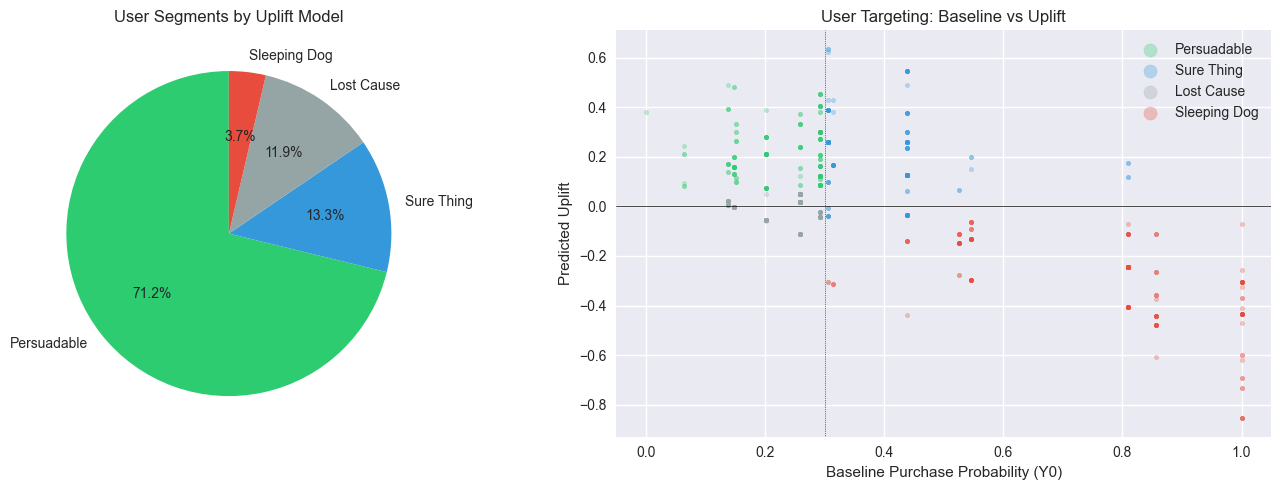

In [9]:
# Segment users based on uplift model
y0_pred = model_control.predict(X_features)
y1_pred = model_treated.predict(X_features)

threshold_y = 0.3
threshold_uplift = 0.05

segments = []
for i in range(N):
    if y0_pred[i] < threshold_y and predicted_uplift[i] > threshold_uplift:
        segments.append('Persuadable')
    elif y0_pred[i] >= threshold_y and predicted_uplift[i] > -threshold_uplift:
        segments.append('Sure Thing')
    elif y0_pred[i] < threshold_y and predicted_uplift[i] <= threshold_uplift:
        segments.append('Lost Cause')
    else:
        segments.append('Sleeping Dog')

segment_counts = Counter(segments)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of segments
labels = ['Persuadable', 'Sure Thing', 'Lost Cause', 'Sleeping Dog']
sizes = [segment_counts.get(s, 0) for s in labels]
colors_pie = ['#2ecc71', '#3498db', '#95a5a6', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[0].set_title('User Segments by Uplift Model')

# Scatter plot: baseline vs uplift
segment_colors = {'Persuadable': '#2ecc71', 'Sure Thing': '#3498db',
                  'Lost Cause': '#95a5a6', 'Sleeping Dog': '#e74c3c'}
for seg in labels:
    mask = np.array(segments) == seg
    axes[1].scatter(y0_pred[mask][:200], predicted_uplift[mask][:200],
                    alpha=0.3, s=10, c=segment_colors[seg], label=seg)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].axvline(x=threshold_y, color='black', linestyle=':', linewidth=0.5)
axes[1].set_xlabel('Baseline Purchase Probability (Y0)')
axes[1].set_ylabel('Predicted Uplift')
axes[1].set_title('User Targeting: Baseline vs Uplift')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

## 8. Exercises

### Exercise 1: Implement Uplift Modeling

In [10]:
# 🏋️ Exercise 1: Implement S-Learner and X-Learner
#
# TODO:
# 1. S-Learner: Train a single model on (X, T) -> Y, then compute
#    uplift as predict(X, T=1) - predict(X, T=0)
# 2. X-Learner: A more sophisticated approach:
#    a. Train T-learner models mu_0, mu_1
#    b. Compute pseudo-effects:
#       For treated: d1_i = Y_i - mu_0(X_i)
#       For control: d0_i = mu_1(X_i) - Y_i
#    c. Train uplift models on pseudo-effects
#    d. Combine: tau(x) = g * tau_1(x) + (1-g) * tau_0(x)
# 3. Compare all three learners (T, S, X) on the uplift curve

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

### Exercise 2: Causal Recommendation Strategy

In [11]:
# 🏋️ Exercise 2: Causal Recommendation Strategy
#
# TODO: Using the uplift model:
# 1. Implement a recommendation strategy that prioritises items with
#    the highest predicted uplift (causal effect) rather than highest
#    predicted conversion
# 2. Simulate 1000 users, each with 20 candidate items
# 3. Compare two strategies:
#    a. Rank by predicted P(purchase) -- standard approach
#    b. Rank by predicted uplift -- causal approach
# 4. Measure the "incremental purchases" from each strategy
#    (purchases that would NOT have happened without the recommendation)

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

### Exercise 3: Sensitivity Analysis

In [12]:
# 🏋️ Exercise 3: Sensitivity Analysis for Unobserved Confounders
#
# TODO: Implement a simple sensitivity analysis:
# 1. Vary the strength of an unobserved confounder from 0 to 2
# 2. For each strength, compute the back-door adjusted ATE
#    (which will be biased because the confounder is unobserved)
# 3. Plot: x = confounder strength, y = estimated ATE
# 4. At what confounder strength does the conclusion flip
#    (ATE goes from positive to negative)?

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

## Summary

In this notebook we covered:

- **Correlation vs causation**: naive estimates overestimate recommendation effects due to confounding
- **Back-door adjustment**: conditioning on observed confounders for unbiased estimates
- **Instrumental variables**: using random assignment as an instrument for causal identification
- **Uplift modeling**: estimating individual treatment effects to target the most responsive users
- **Front-door criterion**: leveraging mediators when confounders are unobserved
- **Deconfounding**: using latent factors as substitute confounders

**Key takeaway:** Causal inference transforms recommendation from "predict what users will click" to "estimate the causal impact of showing an item." This shift enables smarter targeting (focus on persuadable users) and more honest evaluation of recommendation systems.